# Strong Baseline — 100th place (online ensemble + vol-aware sizing)

**Stage 1 baseline — PMLDL 2026 project.**

## Attribution
This notebook is adapted from the public Kaggle notebook
<https://www.kaggle.com/code/tingkaigong/hull-market-prediction-just->
for the *Hull Tactical Market Prediction* competition.
Approach: ElasticNet/XGBoost/LightGBM ensemble at fixed 0.30/0.35/0.35 weights,
retrained online on an 800-row sliding window, with a volatility-regime position
sizer anchored to the metric's 120% volatility ceiling.

All modelling logic is the original author's. Changes made for this project are
limited to **data loading and results saving**, and every one of them is marked
with an `ADDED (PMLDL Stage 1)` comment:

1. hard-coded `/kaggle/input/...` paths replaced by the shared `src` loader;
2. training data trimmed to exclude the held-out public block (last 180
   `date_id`s), which the original notebooks trained on;
3. the `kaggle_evaluation` inference server replaced by an offline replay of
   that block, since the forecasting phase is out of scope;
4. scoring routed through `src.metrics` and persisted via `src.results`.

No author names, usernames or team identifiers are reproduced here.


In [1]:
# ===================== ADDED (PMLDL Stage 1) =====================
# Shared project interface. Replaces all hard-coded /kaggle/input paths and
# ad-hoc scoring. Original modelling logic below is untouched.
# ==================================================================
import sys, pathlib
sys.path.append(str(pathlib.Path.cwd().parent))

from src import *          # see INTERFACE.md
import numpy as np, pandas as pd

set_seed()                 # SEED = 42

# --- universal loader: last 180 date_ids held out (public leaderboard block)
hull = load_dataset()
print(hull)

# --- ADDED: materialise a leak-safe train.csv / test.csv pair so the original
# code can keep using read_csv() without pointing at the public block.
PREPARED = RESULTS_DIR / "prepared"; PREPARED.mkdir(parents=True, exist_ok=True)
hull.train.to_csv(PREPARED / "train.csv", index=False)

_pub = hull.public.copy()
for _c in LOOKAHEAD_COLS:                      # rebuild the API's lagged_* columns
    _pub["lagged_" + _c] = _pub[_c].shift(1).fillna(0.0)
_pub["is_scored"] = True
_pub.drop(columns=list(LOOKAHEAD_COLS)).to_csv(PREPARED / "test.csv", index=False)

PUBLIC_FWD = hull.public["forward_returns"].to_numpy()
PUBLIC_RF  = hull.public["risk_free_rate"].to_numpy()
PUBLIC_Y   = hull.public[TARGET].to_numpy()

def replay_public(predict_fn):
    """ADDED: offline stand-in for kaggle_evaluation - feeds the held-out
    public block to predict() one row at a time, exactly as the API would."""
    import polars as pl
    t = pl.read_csv(PREPARED / "test.csv")
    return np.array([float(predict_fn(t[i:i+1])) for i in range(t.height)])


HullData(train=(7862, 98), public=(180, 98), n_raw_features=94)


[I 2026-09-16 00:45:40,073] A new study created in memory with name: xgb_hyperopt


筛选后的top特征：['I9', 'U2', 'E3', 'V1_S1', 'V7', 'I9_S1', 'V8', 'P2', 'M11', 'P7', 'S5', 'E14', 'P9', 'E5', 'S8', 'M10', 'P8', 'P11', 'V10', 'M8', 'S11', 'S2', 'I4', 'M3', 'M1', 'S4', 'E2', 'I1', 'M4', 'M6', 'V6', 'E6', 'P10', 'M16', 'P6', 'U1', 'M12', 'E19', 'S1', 'V11', 'V1', 'S6', 'I5', 'S3', 'M2', 'P1', 'V5', 'I2', 'I6', 'P4']
50


[I 2026-09-16 00:45:45,059] Trial 0 finished with value: 0.00010623037930997776 and parameters: {'max_depth': 4, 'learning_rate': 0.040115381718776114, 'n_estimators': 180, 'reg_alpha': 0.028689589416714883, 'reg_lambda': 1.3736896182686034}. Best is trial 0 with value: 0.00010623037930997776.
[I 2026-09-16 00:45:58,108] Trial 1 finished with value: 0.00010126976230362117 and parameters: {'max_depth': 6, 'learning_rate': 0.017799367800377063, 'n_estimators': 329, 'reg_alpha': 0.02915768293946765, 'reg_lambda': 0.006097525135894166}. Best is trial 1 with value: 0.00010126976230362117.
[I 2026-09-16 00:46:01,822] Trial 2 finished with value: 9.801049821297472e-05 and parameters: {'max_depth': 8, 'learning_rate': 0.05594718780425907, 'n_estimators': 173, 'reg_alpha': 0.07514603964306249, 'reg_lambda': 0.6777920786604612}. Best is trial 2 with value: 9.801049821297472e-05.
[I 2026-09-16 00:46:09,295] Trial 3 finished with value: 9.713634448485614e-05 and parameters: {'max_depth': 5, 'learn

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000192 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2272
[LightGBM] [Info] Number of data points in the train set: 135, number of used features: 50
[LightGBM] [Info] Start training from score -0.001376
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

[I 2026-09-16 00:47:19,010] Trial 0 finished with value: 9.763126062195524e-05 and parameters: {'max_depth': 3, 'learning_rate': 0.01899351323679892, 'n_estimators': 260, 'reg_alpha': 0.12646930886539856, 'reg_lambda': 0.00793065521377499}. Best is trial 0 with value: 9.763126062195524e-05.


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped training because there are no more leaves that meet the split requirements
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Stopped t

[I 2026-09-16 00:47:50,196] Trial 29 finished with value: 0.00011160516039158443 and parameters: {'max_depth': 6, 'learning_rate': 0.07043928986438483, 'n_estimators': 283, 'reg_alpha': 0.033474374448997514, 'reg_lambda': 0.42948100658442595}. Best is trial 4 with value: 9.290281431786486e-05.
[I 2026-09-16 00:47:50,198] A new study created in memory with name: enet_hyperopt


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2026-09-16 00:47:50,287] Trial 0 finished with value: 9.323574743148544e-05 and parameters: {'alpha': 0.017144158405226546, 'l1_ratio': 0.31775422848888324}. Best is trial 0 with value: 9.323574743148544e-05.
[I 2026-09-16 00:47:50,386] Trial 1 finished with value: 9.867891371830621e-05 and parameters: {'alpha': 0.0015010199697968727, 'l1_ratio': 0.8262479371091715}. Best is trial 0 with value: 9.323574743148544e-05.
[I 2026-09-16 00:47:50,488] Trial 2 finished with value: 9.323574743148544e-05 and parameters: {'alpha': 0.0360935860831992, 'l1_ratio': 0.518463498973566}. Best is trial 0 with value: 9.323574743148544e-05.
[I 2026-09-16 00:47:50,576] Trial 3 finished with value: 9.323574743148544e-05 and parameters: {'alpha': 0.027463006279408286, 'l1_ratio': 0.26217707112412275}. Best is trial 0 with value: 9.323574743148544e-05.
[I 2026-09-16 00:47:50,657] Trial 4 finished with value: 9.323574743148544e-05 and parameters: {'alpha': 0.023163823086070415, 'l1_ratio': 0.237734374393049

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002040 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12317
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 50
[LightGBM] [Info] Start training from score -0.000123
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

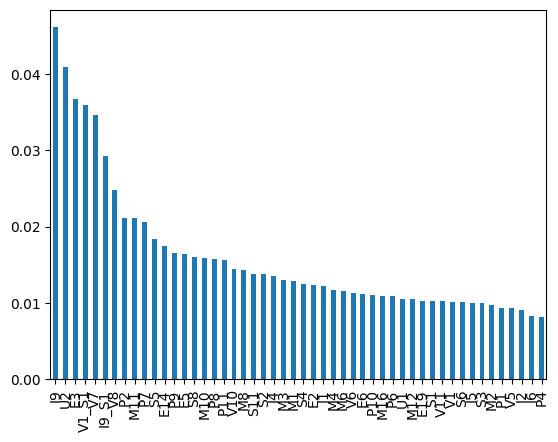

In [2]:
import os
from pathlib import Path
import numpy as np
import polars as pl
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
import xgboost as xgb
import lightgbm as lgb
from dataclasses import dataclass, field
# ADDED: kaggle_evaluation removed (public phase only).
import time
import pandas as pd
from sklearn.model_selection import TimeSeriesSplit
import optuna
from sklearn.metrics import mean_squared_error
import pickle
import warnings
warnings.filterwarnings('ignore')



# ============ PATHS ============
# ADDED: prepared leak-safe split from the setup cell (train.csv + test.csv).
DATA_PATH = PREPARED

# ============ MODEL CONFIGS ============
@dataclass
class ModelParameters:
    enet_alpha: float = 0.01
    enet_l1_ratio: float = 0.5
    xgb_n_estimators: int = 350
    xgb_max_depth: int = 8
    xgb_learning_rate: float = 0.05
    lgb_n_estimators: int = 200
    lgb_max_depth: int = 8
    lgb_learning_rate: float = 0.05
    ensemble_weights: dict = field(default_factory=lambda: {'enet': 0.30, 'xgb': 0.35, 'lgb': 0.35})
    vol_window: int = 20
    signal_multiplier_low_vol: float = 600.0  # For low V1
    signal_multiplier_high_vol: float = 400.0  # For high V1
    min_signal: float = 0.0
    max_signal: float = 2.0
    vol_scaling: float = 1.2
    retrain_freq: int = 1  # Retrain every row
    missing_threshold: float = 0.5
    max_train_rows: int = 800  # Reduced

# Initialize parameters
params = ModelParameters()

# ============ DATA LOADING AND PREPROCESSING ============
def load_trainset() -> pl.DataFrame:
    df = (
        pl.read_csv(DATA_PATH / "train.csv")
        .rename({'market_forward_excess_returns': 'target'})
        .with_columns(pl.exclude('date_id').cast(pl.Float64, strict=False))
        .filter(pl.col('date_id') >= 37)
        .tail(params.max_train_rows)
    )
    missing_counts = {col: df[col].is_null().mean() for col in df.columns}
    feature_cols = [
        col for col, miss_rate in missing_counts.items() 
        if miss_rate <= params.missing_threshold and col not in ['date_id', 'target']
    ]
    keep_cols = ['date_id', 'target'] + feature_cols
    if len(keep_cols) != len(set(keep_cols)):
        raise ValueError(f"Duplicate columns in keep_cols: {keep_cols}")
    return df.select(keep_cols)

def load_testset() -> pl.DataFrame:
    df = (
        pl.read_csv(DATA_PATH / "test.csv")
        .with_columns(pl.exclude('date_id', 'is_scored').cast(pl.Float64, strict=False))
    )
    train_cols = load_trainset().columns
    feature_cols = [col for col in train_cols if col not in ['date_id', 'target']]
    return df.select(['date_id', 'is_scored', 'lagged_market_forward_excess_returns'] + feature_cols)

def create_features(df: pl.DataFrame, is_train: bool = False, median_values: dict = None) -> pl.DataFrame:
    feature_prefixes = ['D', 'E', 'I', 'M', 'P', 'S', 'V']
    base_features = [col for col in df.columns if any(col.startswith(prefix) for prefix in feature_prefixes)]
    
    # Derived features
    required_cols = ['I1', 'I2', 'I7', 'I9', 'M11']
    if all(col in base_features for col in required_cols):
        df = df.with_columns(
            (pl.col("I2") - pl.col("I1")).alias("U1"),
            (pl.col("M11") / ((pl.col("I2") + pl.col("I9") + pl.col("I7")) / 3)).alias("U2")
        )
    else:
        df = df.with_columns(
            pl.lit(0.0).alias("U1"),
            pl.lit(0.0).alias("U2")
        )
    
    # Interaction features
    if 'V1' in base_features and 'S1' in base_features:
        df = df.with_columns((pl.col("V1") * pl.col("S1")).alias("V1_S1"))
    if 'M11' in base_features and 'V1' in base_features:
        df = df.with_columns((pl.col("M11") * pl.col("V1")).alias("M11_V1"))
    if 'I9' in base_features and 'S1' in base_features:
        df = df.with_columns((pl.col("I9") * pl.col("S1")).alias("I9_S1"))
    
    # Training-only features
    if is_train:
        if 'S1' in base_features:
            df = df.with_columns(pl.col("S1").shift(1).alias("S1_lag1"))
        # 新增：特征斜率（过去10天）
        if is_train and 'S1' in base_features:
            df = df.with_columns(
                pl.col("S1").rolling_map(lambda x: np.polyfit(np.arange(len(x)), x, 1)[0] if len(x)>=5 else 0.0, window_size=10).alias("S1_slope_10")
            )
        if 'P1' in base_features:
            df = df.with_columns(pl.col("P1").shift(1).alias("P1_lag1"))
        if 'I9' in base_features:
            df = df.with_columns(pl.col("I9").shift(1).alias("I9_lag1"))
        if 'V1' in base_features:
            df = df.with_columns(pl.col("V1").rolling_mean(window_size=5).alias("V1_roll_mean_5"))
        # 新增：多窗口滚动统计
        if 'V1' in base_features:
            df = df.with_columns([
                pl.col("V1").rolling_mean(window_size=10).alias("V1_roll_mean_10"),
                pl.col("V1").rolling_std(window_size=10).alias("V1_roll_std_10"),
                pl.col("V1").rolling_skew(window_size=20).alias("V1_roll_skew_20"),
                pl.col("V1").ewm_mean(alpha=0.2).alias("V1_ewma_02")  # EWMA平滑
            ])
        if 'target' in df.columns:
            df = df.with_columns(pl.col("target").rolling_std(window_size=5).alias("target_roll_std_5"))

    # 新增：跨特征滚动相关性
    if is_train and all(col in base_features for col in ['V1', 'S1']):
        df = df.with_columns(
            pl.rolling_corr(pl.col("V1"), pl.col("S1"), window_size=10).alias("V1_S1_corr_10")
        )
    # Impute missing values
    for col in base_features:
        if col.startswith('I'):
            df = df.with_columns(pl.col(col).fill_null(pl.col(col).forward_fill()).fill_null(pl.col(col).backward_fill()))
        median = median_values.get(col, df[col].median()) if median_values else df[col].median()
        df = df.with_columns(pl.col(col).fill_null(median if median is not None else 0.0))
    
    # Impute derived and additional features
    derived_features = ["U1", "U2", "V1_S1", "M11_V1", "I9_S1"]
    additional_features = ["S1_lag1", "P1_lag1", "I9_lag1", "V1_roll_mean_5", "target_roll_std_5"] if is_train else []
    for col in derived_features + additional_features:
        if col in df.columns:
            median = median_values.get(col, df[col].median()) if median_values else df[col].median()
            df = df.with_columns(pl.col(col).fill_null(median if median is not None else 0.0))
    
    # Feature list (exclude training-only features)
    features = base_features + derived_features
    select_cols = ["date_id"] + features + (["target"] if is_train else [])
    return df.select(select_cols)

# ============ MODEL TRAINING ============
start_time = time.time()
train = load_trainset()
train = create_features(train, is_train=True)
features = [col for col in train.columns if col not in ['date_id', 'target', 'S1_lag1', 'P1_lag1', 'I9_lag1', 'V1_roll_mean_5', 'target_roll_std_5']]

# Cache median values for imputation (only for features used in model)
median_values = {col: train[col].median() if col in train.columns and train[col].is_null().mean() < 1.0 else 0.0 for col in features}

# Check for NaNs
X_train = train.select(features).to_pandas()
if X_train.isna().any().any():
    raise ValueError(f"NaNs found in X_train for columns: {X_train.columns[X_train.isna().any()].tolist()}")

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
y_train = train['target'].to_pandas()


# 示例：基于XGB特征重要性筛选特征
def select_top_features(X_train, y_train, features, top_k=50,plot=False):
    xgb_temp = xgb.XGBRegressor(n_estimators=100, random_state=42)
    xgb_temp.fit(X_train, y_train)
    imp = pd.Series(xgb_temp.feature_importances_, index=features)
    if plot==True:
        imp.sort_values(ascending=False).head(50).plot.bar()
    top_features = imp.sort_values(ascending=False).head(top_k).index.tolist()
    return top_features

# 训练时调用
global_top_features = select_top_features(X_train, y_train, features, top_k=50,plot=True)
print(f"筛选后的top特征：{global_top_features}")
print(len(global_top_features))
X_train=train.select(global_top_features).to_pandas()
if X_train.isna().any().any():
    raise ValueError(f"NaNs found in X_train for columns: {global_top_features[X_train.isna().any(axis=0)]}")
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)



# ============ 离线超参预调（启动时执行1次） ============
def offline_hyperopt(train_data: pl.DataFrame, features: list, n_trials=50):
    """用历史训练数据预调超参，返回各模型最优参数"""
    X_train = train_data.select(features).to_pandas()
    y_train = train_data['target'].to_pandas()
    tscv = TimeSeriesSplit(n_splits=5)  # 时序交叉验证，避免泄露
    
    # 1. XGBoost调参
    def xgb_objective(trial):
        params = {
            'objective': 'reg:squarederror',
            'max_depth': trial.suggest_int('max_depth', 3, 8),  # 缩小搜索范围，提升效率
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'n_estimators': trial.suggest_int('n_estimators', 150, 350),
            'reg_alpha': trial.suggest_float('reg_alpha', 0.001, 10, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 0.001, 10, log=True),
            'random_state': 42
        }
        scores = []
        for tr_idx, val_idx in tscv.split(X_train):
            X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
            model = xgb.XGBRegressor(**params)
            model.fit(X_tr, y_tr)
            scores.append(mean_squared_error(y_val, model.predict(X_val)))
        return np.mean(scores)
    
    # 2. LightGBM调参（类似XGB，简化搜索范围）
    def lgb_objective(trial):
        params = {
            'objective': 'regression',
            'max_depth': trial.suggest_int('max_depth', 3, 8),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'n_estimators': trial.suggest_int('n_estimators', 150, 300),
            'reg_alpha': trial.suggest_float('reg_alpha', 0.001, 10, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 0.001, 10, log=True),
            'random_state': 42
        }
        scores = []
        for tr_idx, val_idx in tscv.split(X_train):
            X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
            model = lgb.LGBMRegressor(**params)
            model.fit(X_tr, y_tr)
            scores.append(mean_squared_error(y_val, model.predict(X_val)))
        return np.mean(scores)
    
    # 3. 执行调参（限制试验次数，控制启动时间）
    study_xgb = optuna.create_study(direction='minimize', study_name='xgb_hyperopt')
    study_xgb.optimize(xgb_objective, n_trials=30, timeout=300)  # 超时300秒强制停止
    
    study_lgb = optuna.create_study(direction='minimize', study_name='lgb_hyperopt')
    study_lgb.optimize(lgb_objective, n_trials=30, timeout=300)
    
    # 4. ElasticNet调参（简单模型，少试验次数）
    def enet_objective(trial):
        params = {
            'alpha': trial.suggest_float('alpha', 0.001, 0.1, log=True),
            'l1_ratio': trial.suggest_float('l1_ratio', 0.1, 0.9),
            'max_iter': 1000000
        }
        scores = []
        for tr_idx, val_idx in tscv.split(X_train):
            X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
            y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
            scaler = StandardScaler()
            X_tr_scaled = scaler.fit_transform(X_tr)
            X_val_scaled = scaler.transform(X_val)
            model = ElasticNet(**params)
            model.fit(X_tr_scaled, y_tr)
            scores.append(mean_squared_error(y_val, model.predict(X_val_scaled)))
        return np.mean(scores)
    
    study_enet = optuna.create_study(direction='minimize', study_name='enet_hyperopt')
    study_enet.optimize(enet_objective, n_trials=20, timeout=100)
    
    # 返回最优超参
    return {
        'xgb': study_xgb.best_params,
        'lgb': study_lgb.best_params,
        'enet': study_enet.best_params
    }

# 离线预调超参（仅启动时执行1次）
# --- ADDED: Path for checkpoints
_CHECKPOINT_PATH = RESULTS_DIR / 'b_03_checkpoint'
_CHECKPOINT_PATH.mkdir(exist_ok=True)
BESH_HPARAM_PATH = _CHECKPOINT_PATH / 'best_hparams.pkl'

if not os.path.exists(BESH_HPARAM_PATH):  # 缓存最优超参，避免重复调参
    best_hparams = offline_hyperopt(train, global_top_features)
    with open(BESH_HPARAM_PATH, 'wb') as f:
        pickle.dump(best_hparams, f)
else:
    with open(BESH_HPARAM_PATH, 'rb') as f:
        best_hparams = pickle.load(f)


enet_model = ElasticNet(**best_hparams['enet'], max_iter=1000000)
xgb_model = xgb.XGBRegressor(**best_hparams['xgb'], random_state=42)
lgb_model = lgb.LGBMRegressor(**best_hparams['lgb'], random_state=42)

enet_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)
lgb_model.fit(X_train, y_train)

# 检查启动时间（确保不超900秒）
if time.time() - start_time > 900:
    raise RuntimeError("Startup time exceeded 900 seconds")

# ============ 在线轻量调优（周期性触发） ============
def online_light_hyperopt(current_train: pl.DataFrame, features: list, current_hparams: dict, model_type: str):
    """在线轻量调优：基于当前数据，在小范围搜索超参"""
    X_train = current_train.select(features).to_pandas()
    y_train = current_train['target'].to_pandas()
    tscv = TimeSeriesSplit(n_splits=3)  # 减少交叉验证折数，提升速度
    
    # 基于当前超参设置窄搜索范围
    if model_type == 'xgb':
        def objective(trial):
            params = {
                'objective': 'reg:squarederror',
                'max_depth': trial.suggest_int('max_depth', 
                                             max(3, current_hparams['max_depth']-1), 
                                             min(8, current_hparams['max_depth']+1)),  # ±1范围
                'learning_rate': trial.suggest_float('learning_rate', 
                                                   current_hparams['learning_rate']*0.8, 
                                                   current_hparams['learning_rate']*1.2),  # ±20%
                'n_estimators': trial.suggest_int('n_estimators', 
                                                max(100, current_hparams['n_estimators']-50), 
                                                min(400, current_hparams['n_estimators']+50)),  # ±50
                'reg_alpha': trial.suggest_float('reg_alpha', 
                                               current_hparams['reg_alpha']*0.5, 
                                               current_hparams['reg_alpha']*2.0),  # 稍宽范围
                'reg_lambda': trial.suggest_float('reg_lambda', 
                                                current_hparams['reg_lambda']*0.5, 
                                                current_hparams['reg_lambda']*2.0),
                'random_state': 42
            }
            scores = []
            for tr_idx, val_idx in tscv.split(X_train):
                X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
                y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
                model = xgb.XGBRegressor(**params)
                model.fit(X_tr, y_tr)
                scores.append(mean_squared_error(y_val, model.predict(X_val)))
            return np.mean(scores)
    elif model_type == 'lgb':
        # 类似XGB，设置窄搜索范围，省略重复代码
        def objective(trial):
            params = {
                'objective': 'regression',
                'max_depth': trial.suggest_int('max_depth', 
                                             max(3, current_hparams['max_depth']-1), 
                                             min(8, current_hparams['max_depth']+1)),
                'learning_rate': trial.suggest_float('learning_rate', 
                                                   current_hparams['learning_rate']*0.8, 
                                                   current_hparams['learning_rate']*1.2),
                'n_estimators': trial.suggest_int('n_estimators', 
                                                max(100, current_hparams['n_estimators']-50), 
                                                min(350, current_hparams['n_estimators']+50)),
                'reg_alpha': trial.suggest_float('reg_alpha', 
                                               current_hparams['reg_alpha']*0.5, 
                                               current_hparams['reg_alpha']*2.0),
                'reg_lambda': trial.suggest_float('reg_lambda', 
                                                current_hparams['reg_lambda']*0.5, 
                                                current_hparams['reg_lambda']*2.0),
                'random_state': 42
            }
            scores = []
            for tr_idx, val_idx in tscv.split(X_train):
                X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
                y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
                model = lgb.LGBMRegressor(**params)
                model.fit(X_tr, y_tr)
                scores.append(mean_squared_error(y_val, model.predict(X_val)))
            return np.mean(scores)
    else:  # enet
        def objective(trial):
            params = {
                'alpha': trial.suggest_float('alpha', 
                                           current_hparams['alpha']*0.5, 
                                           current_hparams['alpha']*2.0),
                'l1_ratio': trial.suggest_float('l1_ratio', 
                                              max(0.1, current_hparams['l1_ratio']-0.1), 
                                              min(0.9, current_hparams['l1_ratio']+0.1)),
                'max_iter': 1000000
            }
            scores = []
            for tr_idx, val_idx in tscv.split(X_train):
                X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
                y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
                scaler = StandardScaler()
                X_tr_scaled = scaler.fit_transform(X_tr)
                X_val_scaled = scaler.transform(X_val)
                model = ElasticNet(**params)
                model.fit(X_tr_scaled, y_tr)
                scores.append(mean_squared_error(y_val, model.predict(X_val_scaled)))
            return np.mean(scores)
    
    # 轻量调参：仅10次试验，超时15秒停止
    study = optuna.create_study(direction='minimize', study_name=f'online_{model_type}')
    study.optimize(objective, n_trials=10, timeout=15)
    
    return study.best_params

'''
# Train ElasticNet
enet_model = ElasticNet(alpha=params.enet_alpha, l1_ratio=params.enet_l1_ratio, max_iter=1000000)
enet_model.fit(X_train, y_train)

# Train XGBoost
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=params.xgb_n_estimators,
    max_depth=params.xgb_max_depth,
    learning_rate=params.xgb_learning_rate,
    random_state=42
)
xgb_model.fit(X_train, y_train)

# Train LightGBM
lgb_model = lgb.LGBMRegressor(
    objective='regression',
    n_estimators=params.lgb_n_estimators,
    max_depth=params.lgb_max_depth,
    learning_rate=params.lgb_learning_rate,
    random_state=42
)
lgb_model.fit(X_train, y_train)

# Check startup time
if time.time() - start_time > 900:
    raise RuntimeError("Startup time exceeded 900 seconds")
'''

# State for online learning
previous_lagged = None
test_row_count = 0
last_allocation = 0.0
v1_median = train['V1'].median() if 'V1' in train.columns else 0.0


# ============ VOLATILITY ESTIMATION ============
def estimate_volatility(test: pl.DataFrame, train: pl.DataFrame) -> float:
    vol = test['V1'][0] if 'V1' in test.columns else (train['target'].tail(params.vol_window).std() or 0.01)
    recent_returns = train['target'].tail(params.vol_window).to_numpy()
    if len(recent_returns) > 1:
        garch_vol = np.sqrt(0.3 * np.var(recent_returns) + 0.7 * vol**2)
        return max(garch_vol, 0.01)
    return max(vol, 0.01)

# ============ PREDICTION FUNCTION ============
def predict(test: pl.DataFrame) -> float:
    global previous_lagged, train, enet_model, xgb_model, lgb_model, scaler, test_row_count, last_allocation, v1_median,best_hparams
    
    # Online learning: Update training data
    if previous_lagged is not None and 'lagged_market_forward_excess_returns' in previous_lagged.columns:
        append_row = previous_lagged.with_columns(
            pl.col('lagged_market_forward_excess_returns').alias('target')
        )
        append_row = create_features(append_row, is_train=False, median_values=median_values)
        if append_row.height > 0:
            append_row = append_row.with_columns(pl.lit(None).cast(pl.Float64).alias('target'))
            train = train.vstack(append_row.select(['date_id', 'target'] + global_top_features))
            if train.height > params.max_train_rows:
                train = train.tail(params.max_train_rows)
        
        # 关键修改：每50行触发一次在线轻量调优（而非每行重训）
        retrain_freq = params.retrain_freq
        hyperopt_freq = 50  # 调优周期：50行一次
        if test_row_count % hyperopt_freq == 0:
            # 1. 轻量调优各模型超参
            new_xgb_hparams = online_light_hyperopt(train, global_top_features, best_hparams['xgb'], 'xgb')
            new_lgb_hparams = online_light_hyperopt(train, global_top_features, best_hparams['lgb'], 'lgb')
            new_enet_hparams = online_light_hyperopt(train, global_top_features, best_hparams['enet'], 'enet')
            
            # 2. 用新超参训练模型
            X_train = scaler.fit_transform(train.select(global_top_features).to_pandas())
            y_train = train['target'].to_pandas()
            
            enet_model = ElasticNet(**new_enet_hparams, max_iter=1000000)
            xgb_model = xgb.XGBRegressor(**new_xgb_hparams, random_state=42)
            lgb_model = lgb.LGBMRegressor(**new_lgb_hparams, random_state=42)
            
            enet_model.fit(X_train, y_train)
            xgb_model.fit(X_train, y_train)
            lgb_model.fit(X_train, y_train)
            
            # 3. 更新最优超参缓存
            best_hparams = {
                'xgb': new_xgb_hparams,
                'lgb': new_lgb_hparams,
                'enet': new_enet_hparams
            }
        elif test_row_count % retrain_freq == 0:
            # 非调优周期：用当前超参全量重训（原有逻辑）
            X_train = scaler.fit_transform(train.select(features).to_pandas())
            y_train = train['target'].to_pandas()
            enet_model.fit(X_train, y_train)
            xgb_model.fit(X_train, y_train)
            lgb_model.fit(X_train, y_train)
    
    # Preprocess test data
    test = create_features(test, is_train=False, median_values=median_values)
    
    # Ensure no NaNs in test data
    X_test = test.select(global_top_features).to_pandas()
    if X_test.isna().any().any():
        raise ValueError(f"NaNs found in X_test for columns: {X_test.columns[X_test.isna().any()].tolist()}")
    
    X_test = scaler.transform(X_test)
    
    # Ensemble prediction
    enet_pred = enet_model.predict(X_test)[0]
    xgb_pred = xgb_model.predict(X_test)[0]
    lgb_pred = lgb_model.predict(X_test)[0]
    raw_pred = (params.ensemble_weights['enet'] * enet_pred +
                params.ensemble_weights['xgb'] * xgb_pred +
                params.ensemble_weights['lgb'] * lgb_pred)
    
    # Estimate volatility and dynamic signal multiplier
    vol = estimate_volatility(test, train)
    signal_multiplier = params.signal_multiplier_low_vol if ('V1' in test.columns and test['V1'][0] < v1_median) else params.signal_multiplier_high_vol
    
    # Convert to signal
    signal = np.clip(
        raw_pred * signal_multiplier,
        params.min_signal,
        params.max_signal
    )
    
    # Volatility-adjusted allocation
    allocation = min(params.max_signal, max(params.min_signal, signal / (vol * params.vol_scaling)))
    
    # Smooth allocation
    transaction_cost = 0.00003  # Reduced to 0.003%
    allocation = (0.75 * allocation + 0.25 * last_allocation) * (1 - transaction_cost)  # Adjusted smoothing
    last_allocation = allocation
    
    # Update state
    previous_lagged = test
    test_row_count += 1
    
    return float(allocation)

# ============ LAUNCH SERVER ============
# ADDED: inference server replaced by the offline replay in the final cell.

In [4]:
MODEL_NAME = "online_ensemble_100th"
MODEL_NOTES = "Streaming ENet+XGB+LGBM ensemble, 800-row window, vol-anchored sizer"

# ===================== ADDED (PMLDL Stage 1) =====================
# Universal results saver. Replays the held-out public block through predict()
# and records the run in results/leaderboard.csv.
# ==================================================================
allocations = replay_public(predict)

metrics = evaluate(
    PUBLIC_Y,
    allocations,               # allocation doubles as the ranking signal here
    weights=allocations,
    forward_returns=PUBLIC_FWD,
    risk_free_rate=PUBLIC_RF,
)
print({k: round(v, 4) for k, v in metrics.items() if isinstance(v, float)})

save_result(
    model=MODEL_NAME, stage="baseline", metrics=metrics,
    split="public", notes=MODEL_NOTES,
)

{'rmse': 0.5459, 'r2': -2800.9796, 'spearman_ic': 0.0001, 'hit_rate': 0.55, 'modified_sharpe': 0.2744, 'sharpe': 0.725, 'vol_ratio': 0.4732, 'vol_penalty': 1.0, 'return_penalty': 2.6418, 'bounds_violation': 0.0, 'ann_return': 0.0997, 'ann_volatility': 0.0774, 'max_drawdown': -0.0397, 'benchmark_sharpe': 1.208, 'mean_weight': 0.2628, 'weight_turnover': 0.2086}


WindowsPath('C:/Users/bobs/Desktop/Новая папка (3)/PMDL-Project-Market-Prediction/results/leaderboard.csv')

In [5]:
display(compare(split="public"))

,model,stage,split,spearman_ic_mean,spearman_ic,rmse_mean,rmse,modified_sharpe_mean,modified_sharpe,sharpe_mean,sharpe,vol_ratio_mean,vol_ratio
0,hybrid_domain_lgbm,proposed,public,NaN,0.180720,NaN,0.010549,NaN,1.802853,NaN,1.802853,NaN,0.803328
1,lgbm_61st,baseline,public,NaN,0.047796,NaN,0.631812,NaN,0.997153,NaN,1.185332,NaN,0.726148
2,improved_ensemble,improved,public,NaN,0.043331,NaN,1.333474,NaN,0.010594,NaN,0.047391,NaN,1.309702
3,elasticnet_leak_safe,baseline,public,NaN,-0.135918,NaN,0.121817,NaN,0.387571,NaN,1.385695,NaN,0.104900
4,online_ensemble_100th,baseline,public,NaN,0.000086,NaN,0.545907,NaN,0.274439,NaN,0.725019,NaN,0.473175
